In [50]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [198]:
# pyFBS.example_lab_testbench["meas"]

In [199]:
# pyFBS.example_lab_testbench

In [200]:
# pyFBS.example_auto_testbench

In [55]:
stl = pyFBS.example_lab_testbench["STL"]["B"]
xlsx = pyFBS.example_lab_testbench["meas"]["xlsx"]

full_file = pyFBS.example_lab_testbench["FEM"]["B_full"]
ress_file = pyFBS.example_lab_testbench["FEM"]["B_rst"]

In [56]:
MK = pyFBS.MK_model(ress_file,full_file,no_modes = 100,recalculate = False)

In [57]:
view3D = pyFBS.view3D(show_origin= True)

In [60]:
#view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = .1)

(PolyData (0x23f8901d528)
   N Cells:	1230
   N Points:	597
   X Bounds:	1.072e+01, 3.504e+02
   Y Bounds:	2.050e+02, 4.114e+02
   Z Bounds:	-1.300e+01, 2.700e+01
   N Arrays:	0, (vtkRenderingOpenGL2Python.vtkOpenGLActor)0000023F8901D828)

In [70]:
view3D.plot.add_mesh(MK.mesh, scalars = np.ones(MK.mesh.points.shape[0]),show_scalar_bar = False,name = "mesh",cmap = "coolwarm",show_edges = True,render_points_as_spheres  = True,style = "surface")

(vtkRenderingOpenGL2Python.vtkOpenGLActor)0000023F2EECBBE8

In [71]:
select_mode = 7
_modeshape = MK.get_modeshape(select_mode)

mode_dict = dict_animation(_modeshape,"modeshape",pts = MK.pts,mesh = MK.mesh)
view3D.add_modeshape(mode_dict,run_animation = True)

In [95]:
df_acc = pd.read_excel(xlsx, sheet_name='Sensors_B')
view3D.show_acc(df_acc,overwrite = True)
#view3D.label_imp(df_imp)
#df_imp

In [132]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_B')
view3D.show_imp(df_imp,overwrite = True)
#view3D.label_imp(df_imp)
#df_imp

In [133]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_B')
view3D.show_chn(df_chn)
#df_chn

In [33]:
df_chn_up = MK.update_locations_df(df_chn)
df_imp_up = MK.update_locations_df(df_imp)

view3D.show_imp(df_imp_up, color = "k",overwrite = False)


In [72]:
MK.FRF_synth(df_chn,df_imp,f_start = 0,modal_damping = 0.003,frf_type = "accelerance")

In [40]:
freq, Y_AB_exp = np.load(r"../data/lab_testbench/Measurements/Y_B.p",allow_pickle = True)

In [111]:
from scipy.spatial.transform import Rotation as R


In [143]:
df_acc

,Name,Description,Type,Size,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Orientation_1,Orientation_2,Orientation_3
0,Sensor 3,AM_AB_final,NaN,0.0102,3,1,Acceleration,m/s^2,0.019417,0.342181,0.032100,0,0.00000,-50.198340
1,Sensor 4,AM_AB_final,NaN,0.0102,4,1,Acceleration,m/s^2,0.033939,0.369125,-0.007519,0,-90.00000,-49.999999
2,Sensor 5,AM_AB_final,NaN,0.0102,5,1,Acceleration,m/s^2,0.068643,0.344110,0.019960,0,-89.99993,-140.000005
3,Sensor 6,AM_AB_final,NaN,0.0102,6,10,Acceleration,m/s^2,0.111590,0.271543,0.032100,0,0.00000,95.075237
4,Sensor 7,AM_AB_final,NaN,0.0102,7,10,Acceleration,m/s^2,0.183386,0.384476,0.032100,0,0.00000,-51.160633
5,Sensor 8,AM_AB_final,NaN,0.0102,8,10,Acceleration,m/s^2,0.241944,0.294323,-0.004390,0,-90.00000,40.000006
6,Sensor 9,AM_AB_final,NaN,0.0102,9,10,Acceleration,m/s^2,0.315197,0.207024,0.020318,0,-90.00000,40.000006


In [197]:
df_chn_up = generate_sensors_from_channels(df_chn)
generate_channels_from_sensors(df_chn_up)


Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.


,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
0,S1x,None,None,None,None,None,None,None,None,0.019417,0.342181,0.0321,0.640132,-0.768265,-0
1,S1y,None,None,None,None,None,None,None,None,0.019417,0.342181,0.0321,0.768265,0.640132,0
2,S1z,None,None,None,None,None,None,None,None,0.019417,0.342181,0.0321,0,-0,1
3,S2x,None,None,None,None,None,None,None,None,0.0339388,0.369125,-0.00751875,0,0,1
4,S2y,None,None,None,None,None,None,None,None,0.0339388,0.369125,-0.00751875,0.766044,0.642788,0
5,S2z,None,None,None,None,None,None,None,None,0.0339388,0.369125,-0.00751875,-0.642788,0.766044,0
6,S3x,None,None,None,None,None,None,None,None,0.0686431,0.34411,0.0199603,-9.41785e-07,-7.90252e-07,1
7,S3y,None,None,None,None,None,None,None,None,0.0686431,0.34411,0.0199603,0.642788,-0.766044,-5.55112e-17
8,S3z,None,None,None,None,None,None,None,None,0.0686431,0.34411,0.0199603,0.766044,0.642788,1.22941e-06
9,S4x,None,None,None,None,None,None,None,None,0.11159,0.271543,0.0321,-0.0884638,0.996079,0


In [165]:
df_chn_up["Orientation_3"]

0   -50.1983
0          0
0       -140
0    95.0752
0   -51.1606
0          0
0          0
Name: Orientation_3, dtype: object

In [191]:
generate_channels_from_sensors(df_chn_up)

KeyError: 1

In [105]:
from pyFBS.utility import *

In [99]:
gen_channels_from_sensors(df_acc)

,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
0,Sensor 3x,AM_AB_final,NaN,None,None,None,None,None,1,0.019417,0.342181,0.0321,0.640132,-0.768265,-0
0,Sensor 3y,AM_AB_final,NaN,None,None,None,None,None,1,0.019417,0.342181,0.0321,0.768265,0.640132,0
0,Sensor 3z,AM_AB_final,NaN,None,None,None,None,None,1,0.019417,0.342181,0.0321,0,-0,1
0,Sensor 4x,AM_AB_final,NaN,None,None,None,None,None,1,0.0339388,0.369125,-0.00751875,0,0,1
0,Sensor 4y,AM_AB_final,NaN,None,None,None,None,None,1,0.0339388,0.369125,-0.00751875,0.766044,0.642788,0
0,Sensor 4z,AM_AB_final,NaN,None,None,None,None,None,1,0.0339388,0.369125,-0.00751875,-0.642788,0.766044,0
0,Sensor 5x,AM_AB_final,NaN,None,None,None,None,None,1,0.0686431,0.34411,0.0199603,-9.41924e-07,-7.90368e-07,1
0,Sensor 5y,AM_AB_final,NaN,None,None,None,None,None,1,0.0686431,0.34411,0.0199603,0.642788,-0.766044,-5.55112e-17
0,Sensor 5z,AM_AB_final,NaN,None,None,None,None,None,1,0.0686431,0.34411,0.0199603,0.766044,0.642788,1.22959e-06
0,Sensor 6x,AM_AB_final,NaN,None,None,None,None,None,10,0.11159,0.271543,0.0321,-0.0884638,0.996079,0


,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
3,Sensor 4,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,4,1,0.033939,0.369125,-0.007519,0.0,0.0,1.0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
0,Impact 7,AM_AB_final,7,1,Force,N,0.046036,0.323204,0.027,0.0,0.0,-1.0


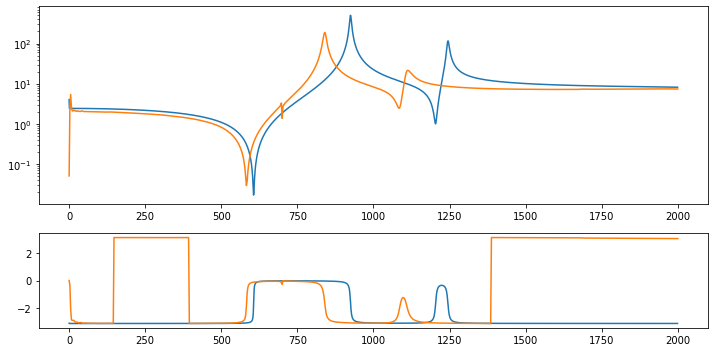

In [74]:
plt.figure(figsize = (12,8))

s1 = 3
s2 = 0

display(df_chn.iloc[[s1]])
display(df_imp.iloc[[s2]])

plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]))
plt.semilogy(freq,np.abs(Y_AB_exp[s1,s2]))


plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_exp[s1,s2]))



In [ ]:
#df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
#df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')

df_chn = df_chn_up
df_imp = df_imp_up

df_vp = pd.read_excel(xlsx, sheet_name='VP_Channels')
df_vpref = pd.read_excel(xlsx, sheet_name='VP_RefChannels')

vpt = pyFBS.VPT(df_chn,df_imp,df_vp,df_vpref)

In [ ]:
frf_exp = np.transpose(Y_AB_exp,(2,0,1))

vpt.apply_VPT(MK.FRF,MK.FRF)
vpt.consistency([1],[1])

In [ ]:
vpt.vptData.shape

In [ ]:
plt.semilogy(np.abs(vpt.u[8,:]))
plt.semilogy(np.abs(vpt.u_f[8,:]))

In [ ]:
plt.bar(range(9),vpt.specific_sensor)

In [ ]:
plt.bar(range(9),vpt.specific_impact)

In [ ]:
Y_SEMM_coh = np.zeros((24,24))

for i in range(24):
    for j in range(24):
        Y_SEMM_coh[i,j] = coh_frf(vpt.vptData[:,i,j], vpt.vptData[:,j,i])

plt.imshow(Y_SEMM_coh)

In [201]:

# create a mesh and identify some scalars you wish to plot
mesh = pv.Sphere()
z = mesh.points[:, 2]

# Plot using the ITKplotter
pl = pv.PlotterITK()
pl.add_mesh(mesh, scalars=z, smooth_shading=True)
pl.show(True)

Viewer(geometries=[{'vtkClass': 'vtkPolyData', 'points': {'vtkClass': 'vtkPoints', 'name': '_points', 'numberO…